veremos si cambia algo el codigo para no grafico en one vs all

In [1]:
# Manejo de directorios y rutas
import os

# Computación numérica y manejo de matrices
import numpy as np

# Manejo y preprocesamiento de datos
import pandas as pd

# Librerías para graficación
from matplotlib import pyplot

# Mostrar gráficos dentro del cuadernillo
%matplotlib inline
import matplotlib.pyplot as plt

import random

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("CUDA de PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

#si queremos mejorar este codigo deberiamos de usar el siguiente para que se use cuda siempre y cuando existan esos nuvles y si no permanecer en cpu
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#print(f'Dispositivo en uso: {device}')
#print(f'Versión de PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cu132
CUDA disponible: True
CUDA de PyTorch: 13.2
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [3]:
df_emnist = pd.read_csv("dt_n/Iris.csv")

print("Forma del dataset:", df_emnist.shape)

Forma del dataset: (150, 6)


In [4]:
print("informacion de las columnas del dataset:", df_emnist.info())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
informacion de las columnas del dataset: None


In [5]:
df_emnist.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
datos_modelo_emnist = df_emnist.copy()

print("Dataset original:", df_emnist.shape)
print("Copia para el modelo:", datos_modelo_emnist.shape)

Dataset original: (150, 6)
Copia para el modelo: (150, 6)


In [7]:
datos_modelo_emnist = datos_modelo_emnist.drop(columns=["Id",])

In [8]:
print("Copia para el modelo:", datos_modelo_emnist.shape)

Copia para el modelo: (150, 5)


In [9]:
from sklearn.preprocessing import LabelEncoder

X_emnist = datos_modelo_emnist.drop(columns=["Species"])
y_text_emnist = datos_modelo_emnist["Species"]


print(y_text_emnist.value_counts())

le = LabelEncoder()
y_emnist = le.fit_transform(y_text_emnist)   

print("Clases codificadas:", le.classes_[:5], "...")

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64
Clases codificadas: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica'] ...


In [10]:
from sklearn.model_selection import train_test_split

X_train_emnist, X_test_emnist, y_train_emnist, y_test_emnist = train_test_split(
    X_emnist, y_emnist,
    test_size=0.20,
    random_state=42,
    stratify=y_emnist
)

print("X_train:", X_train_emnist.shape)
print("X_test:", X_test_emnist.shape)
print("y_train:", y_train_emnist.shape)
print("y_test:", y_test_emnist.shape)

X_train: (120, 4)
X_test: (30, 4)
y_train: (120,)
y_test: (30,)


In [11]:
y_emnist = pd.Series(y_emnist, name='target')
y_train_emnist = pd.Series(y_train_emnist, name='target')
y_test_emnist  = pd.Series(y_test_emnist, name='target')

In [12]:
print("Distribución original:")
print(y_emnist.value_counts())
print(y_emnist.value_counts(normalize=True))

print("\nDistribución en TRAIN:")
print(y_train_emnist.value_counts())
print(y_train_emnist.value_counts(normalize=True))

print("\nDistribución en TEST:")
print(y_test_emnist.value_counts())
print(y_test_emnist.value_counts(normalize=True))

Distribución original:
target
0    50
1    50
2    50
Name: count, dtype: int64
target
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64

Distribución en TRAIN:
target
0    40
2    40
1    40
Name: count, dtype: int64
target
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64

Distribución en TEST:
target
0    10
2    10
1    10
Name: count, dtype: int64
target
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64


In [13]:
X_emnist = X_emnist.to_numpy()
y_emnist = y_emnist.to_numpy()

In [14]:
def featureNormalize(X):

    X_norm = X.copy()

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [15]:
X_train_emnist, mu, sigma = featureNormalize(X_train_emnist)

X_test_emnist = (X_test_emnist - mu) / sigma

In [16]:
X_train_emnist = X_train_emnist.to_numpy()
y_train_emnist = y_train_emnist.to_numpy()
X_test_emnist = X_test_emnist.to_numpy()
y_test_emnist = y_test_emnist.to_numpy()

In [17]:
import torch

X_train_emnist_t = torch.tensor(
    X_train_emnist,
    dtype=torch.float32
).cuda()

X_test_emnist_t = torch.tensor(
    X_test_emnist,
    dtype=torch.float32
).cuda()

y_train_emnist_t = torch.tensor(
    y_train_emnist,
    dtype=torch.long
).cuda()

y_test_emnist_t = torch.tensor(
    y_test_emnist,
    dtype=torch.long
).cuda()

In [21]:
D_in, H1, D_out = 4, 10, 3
model_emnist = torch.nn.Sequential(
torch.nn.Linear(D_in, H1),
torch.nn.ReLU(),
torch.nn.Dropout(0.2),
torch.nn.Linear(H1, D_out),
).cuda()

criterion_emnist = torch.nn.CrossEntropyLoss()

optimizer_emnist = torch.optim.Adam(model_emnist.parameters(), lr=0.008)

epochs = 2000
log_each = 10

l_emnist = []
val_l = []          # <<< NUEVO: guardamos la pérdida de validación por epoch

best_val_loss = float("inf")   # <<< NUEVO: mejor pérdida de validación vista hasta ahora
patience = 10                 # <<< NUEVO: epochs de tolerancia sin mejora antes de parar
step = 0                       # <<< NUEVO: contador de epochs sin mejora


model_emnist.train()

for e in range(1, epochs + 1):

    # Forward
    y_pred_emnist = model_emnist(X_train_emnist_t)

    # Loss
    loss_emnist = criterion_emnist(
        y_pred_emnist,
        y_train_emnist_t
    )

    l_emnist.append(loss_emnist.item())

    # Ponemos a cero los gradientes
    optimizer_emnist.zero_grad()

    # Backpropagation
    loss_emnist.backward()

    # Actualizamos los pesos
    optimizer_emnist.step()


    # <<< NUEVO: bloque completo de validación + early stopping >>>
    model_emnist.eval()
    with torch.no_grad():
            val_logits = model_emnist(X_test_emnist_t)
            val_loss = criterion_emnist(
                val_logits,
                y_test_emnist_t
            )
    val_l.append(val_loss.item())
    
    if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            torch.save(model_emnist.state_dict(), "ckpt_no_graf_balance.pt")
            step = 0
    else:
            step += 1
    
    if step > patience:
            print(f"Early stopping en epoch {e} (sin mejora en {patience} epochs)")
            break
        # <<< FIN bloque nuevo >>>


    if not e % log_each:
            print(
                f"Epoch {e}/{epochs} "
                f"Loss {loss_emnist.item():.5f} "
                f"Val_loss {val_loss.item():.5f}"     # <<< NUEVO en el print
            )
    
    model_emnist.load_state_dict(torch.load("ckpt_no_graf_balance.pt"))

Epoch 10/2000 Loss 0.82109 Val_loss 0.80290
Epoch 20/2000 Loss 0.57185 Val_loss 0.57491
Epoch 30/2000 Loss 0.41188 Val_loss 0.43321
Epoch 40/2000 Loss 0.31178 Val_loss 0.34501
Epoch 50/2000 Loss 0.24960 Val_loss 0.28876
Epoch 60/2000 Loss 0.20528 Val_loss 0.24650
Epoch 70/2000 Loss 0.17009 Val_loss 0.20891
Epoch 80/2000 Loss 0.14286 Val_loss 0.17738
Epoch 90/2000 Loss 0.12193 Val_loss 0.15290
Epoch 100/2000 Loss 0.10652 Val_loss 0.13556
Epoch 110/2000 Loss 0.09479 Val_loss 0.12113
Epoch 120/2000 Loss 0.08558 Val_loss 0.10948
Epoch 130/2000 Loss 0.07838 Val_loss 0.09995
Epoch 140/2000 Loss 0.07263 Val_loss 0.09214
Epoch 150/2000 Loss 0.06790 Val_loss 0.08577
Epoch 160/2000 Loss 0.06408 Val_loss 0.08068
Epoch 170/2000 Loss 0.06100 Val_loss 0.07659
Epoch 180/2000 Loss 0.05840 Val_loss 0.07308
Epoch 190/2000 Loss 0.05618 Val_loss 0.07004
Epoch 200/2000 Loss 0.05425 Val_loss 0.06739
Epoch 210/2000 Loss 0.05257 Val_loss 0.06521
Epoch 220/2000 Loss 0.05109 Val_loss 0.06361
Epoch 230/2000 Loss

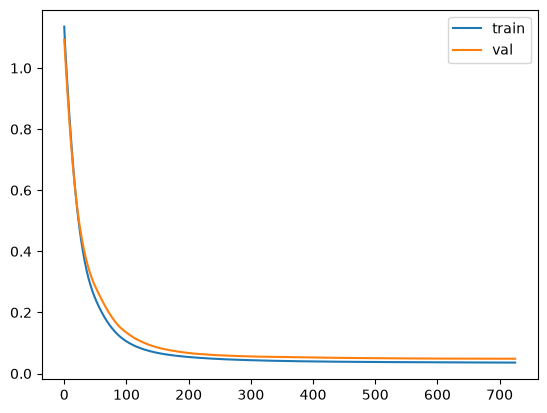

In [22]:
plt.plot(l_emnist, label="train")
plt.plot(val_l, label="val")
plt.legend()

In [23]:
from sklearn.metrics import accuracy_score

def evaluate_emnist(x):

    model_emnist.eval()

    logits = model_emnist(x)

    probabilidades = torch.softmax(logits, dim=1)

    predicciones = torch.argmax(
        probabilidades,
        dim=1
    )

    return predicciones

In [24]:
y_pred_emnist = evaluate_emnist(
    X_test_emnist_t
)

accuracy_emnist = accuracy_score(
    y_test_emnist_t.cpu().numpy(),
    y_pred_emnist.cpu().numpy()
)

print(f"Accuracy: {accuracy_emnist * 100:.2f}%")

Accuracy: 96.67%
